In [1]:
# Run this as the VERY FIRST cell after reloading
# It will trigger a camera permission popup from Chrome

from IPython.display import display, Javascript

display(Javascript('''
    navigator.mediaDevices.getUserMedia({video: true})
        .then(stream => {
            element.textContent = "✅ Camera access GRANTED!";
            stream.getTracks().forEach(track => track.stop());
        })
        .catch(err => {
            element.textContent = "❌ Still blocked: " + err.message;
        });
'''))


<IPython.core.display.Javascript object>

In [2]:
# Then mount Drive:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Cell 1 — Creates config.py on your Drive
import os

project_path = "/content/drive/MyDrive/CV_PROJECT"

# Create folders if they don't exist yet
os.makedirs(project_path, exist_ok=True)
os.makedirs(os.path.join(project_path, "model"), exist_ok=True)

# Write config.py directly from Colab
config_code = '''# config.py
import os

BASE_DIR = "/content/drive/MyDrive/CV_PROJECT"
MODEL_PATH = os.path.join(BASE_DIR, "model", "isl_model.pkl")

FRAME_WIDTH = 640
FRAME_HEIGHT = 480

BUFFER_SIZE = 10
MAX_HANDS = 2
DETECTION_CONFIDENCE = 0.7
TRACKING_CONFIDENCE = 0.7
'''

with open(os.path.join(project_path, "config.py"), "w") as f:
    f.write(config_code)

print("✅ config.py created successfully!")

✅ config.py created successfully!


In [4]:
# Cell 2 — Run this FIRST, every time you open Colab
import sys
import os

# Tell Python to look in your project folder for modules
project_path = "/content/drive/MyDrive/CV_PROJECT"
sys.path.insert(0, project_path)

print("✅ Project path added:", project_path)
print("📁 Files found:", os.listdir(project_path))

✅ Project path added: /content/drive/MyDrive/CV_PROJECT
📁 Files found: ['speech.ipynb', 'model', '__pycache__', 'data_set', 'collected_data.gsheet', 'data', 'ui_overlay.py', '2_MediaPipe.ipynb', '6_UI.ipynb', 'config.py', 'model_loader.py', 'utils.py', '3_Landmark_Extraction.ipynb', '4_model_training.ipynb', '5_prediction_logic.ipynb', '1_main.ipynb']


📸 Capturing from webcam...


<IPython.core.display.Javascript object>

⏳ Camera warming up... please wait ~2 seconds
✅ Frame captured! Shape: (480, 640, 3)


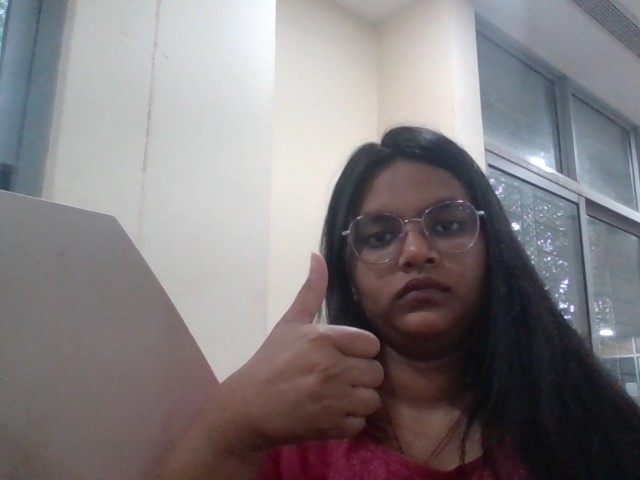

In [5]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io

def capture_frame_from_colab():
    """
    Captures one frame from webcam.
    Fixed version - properly waits for frame before stopping camera.
    """
    js_code = Javascript('''
        async function captureFrame() {
            const video = document.createElement('video');
            video.style.display = 'none';
            document.body.appendChild(video);

            // Start camera
            const stream = await navigator.mediaDevices.getUserMedia({
                video: { width: 640, height: 480 }
            });
            video.srcObject = stream;

            // Wait for video to be truly ready
            await new Promise(resolve => {
                video.onloadedmetadata = () => {
                    video.play().then(resolve);
                };
            });

            // Extra wait for camera to warm up (brightness to settle)
            await new Promise(resolve => setTimeout(resolve, 1500));

            // Take the snapshot
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth || 640;
            canvas.height = video.videoHeight || 480;
            canvas.getContext('2d').drawImage(video, 0, 0);

            // NOW stop the camera (after snapshot is taken)
            stream.getTracks().forEach(track => track.stop());
            video.remove();

            return canvas.toDataURL('image/jpeg', 0.9);
        }

        // This sends the result back to Python
        captureFrame().then(result => {
            element.textContent = result;
        }).catch(err => {
            element.textContent = 'ERROR: ' + err.message;
        });
    ''')

    display(js_code)

    print("⏳ Camera warming up... please wait ~2 seconds")
    result = eval_js('captureFrame()', timeout_sec=15)  # give it enough time

    # Check if something went wrong on JS side
    if result.startswith('ERROR'):
        print(f"❌ JS Error: {result}")
        return None

    # Decode base64 image → NumPy array
    image_bytes = b64decode(result.split(',')[1])
    image_pil = Image.open(io.BytesIO(image_bytes))
    frame = np.array(image_pil)

    # Convert RGB → BGR for OpenCV
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    return frame


def show_frame(frame):
    """Displays a BGR OpenCV frame inside the notebook."""
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))


# --- Run it ---
print("📸 Capturing from webcam...")
frame = capture_frame_from_colab()

if frame is not None:
    frame = cv2.resize(frame, (640, 480))
    print(f"✅ Frame captured! Shape: {frame.shape}")
    show_frame(frame)
else:
    print("❌ Frame capture failed. See error above.")

In [6]:
# In a Colab cell, run:
!pip install opencv-python-headless mediapipe pyttsx3 scikit-learn pillow -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.3 MB/s eta 0:00:00


In [7]:
# things done in this notebook :
# config.py created
# webcam capture working
# frame dispayed in notebook